In [1]:
import pathlib

import altair as alt
import geopandas as gpd
import laspy
import logging
import numpy as np
import open3d as o3d
import pyproj
import shapely 

import pitchmark
import pitchmark.osm
import pitchmark.lidar

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [2]:
logging.basicConfig(level=logging.INFO)

In [3]:
logging.getLogger()

<RootLogger root (INFO)>

In [47]:
alt.renderers.enable('mimetype')
alt.renderers

RendererRegistry(active='mimetype', registered=['colab', 'default', 'html', 'json', 'jupyterlab', 'kaggle', 'mimetype', 'nteract', 'png', 'svg', 'zeppelin'])

In [4]:
logging.warning("abc")
logging.info("def")

INFO:root:def


In [5]:
pathlib.Path().cwd()

WindowsPath('c:/Users/istvan/OneDrive/dev/pitchmark/notes')

In [6]:
pathlib.Path().cwd().parent

WindowsPath('c:/Users/istvan/OneDrive/dev/pitchmark')

In [7]:
map_path = pathlib.Path().cwd().parent / "data-raw" / "OpenStreetMap" / "augusta_national" / "map.osm"
handler = pitchmark.osm.GolfHandler()
handler.apply_file(map_path)
fc = handler.feature_collection
augusta_national = pitchmark.Course.from_featurecollection(fc)

In [8]:
geoseries = augusta_national.gdf.geometry
geoseries

168    POLYGON ((-364.377 210.856, -364.295 207.363, ...
222    POLYGON ((-399.804 -688.022, -398.869 -692.801...
158    POLYGON ((-167.382 -395.922, -159.639 -418.350...
138    POLYGON ((-106.194 -302.804, -105.249 -314.509...
135    POLYGON ((-181.484 -183.993, -181.413 -186.310...
                             ...                        
112    POLYGON ((-183.500 -421.879, -177.088 -422.219...
34     POLYGON ((-94.679 -80.650, -94.435 -81.656, -9...
161    POLYGON ((-245.263 -280.750, -230.011 -333.381...
32     POLYGON ((-179.462 -186.079, -179.370 -186.953...
31     POLYGON ((-173.079 -166.866, -173.039 -167.715...
Name: geometry, Length: 204, dtype: geometry

In [9]:
azalea = augusta_national.holes[12]
azalea

Hole(hole_number=13, name='Azalea', path=<LINESTRING (-82.024 33.494, -82.024 33.496, -82.025 33.497, -82.026 33.497)>)

In [10]:
redbud = augusta_national.holes[15]
redbud

Hole(hole_number=16, name='Redbud', path=<LINESTRING (-82.026 33.498, -82.026 33.5)>)

In [11]:
folder = pathlib.Path().cwd().parent / "data-raw" / "USGS_LIDAR"
files = [
    "USGS_LPC_GA_Statewide_2018_B18_DRRA_e1284n1253.laz",
    "USGS_LPC_GA_Statewide_2018_B18_DRRA_e1284n1254.laz",
    "USGS_LPC_GA_Statewide_2018_B18_DRRA_e1285n1253.laz",
    "USGS_LPC_GA_Statewide_2018_B18_DRRA_e1285n1254.laz",
]
paths = [folder / file for file in files]
paths

[WindowsPath('c:/Users/istvan/OneDrive/dev/pitchmark/data-raw/USGS_LIDAR/USGS_LPC_GA_Statewide_2018_B18_DRRA_e1284n1253.laz'),
 WindowsPath('c:/Users/istvan/OneDrive/dev/pitchmark/data-raw/USGS_LIDAR/USGS_LPC_GA_Statewide_2018_B18_DRRA_e1284n1254.laz'),
 WindowsPath('c:/Users/istvan/OneDrive/dev/pitchmark/data-raw/USGS_LIDAR/USGS_LPC_GA_Statewide_2018_B18_DRRA_e1285n1253.laz'),
 WindowsPath('c:/Users/istvan/OneDrive/dev/pitchmark/data-raw/USGS_LIDAR/USGS_LPC_GA_Statewide_2018_B18_DRRA_e1285n1254.laz')]

In [12]:
# las_classes = [
#     pitchmark.lidar.las.LasClassification.unclassified,
#     pitchmark.lidar.las.LasClassification.ground,
# ]
# pitchmark.lidar.las.clip_to_geoseries(
#     paths,
#     geoseries,
#     classification_filter=las_classes,
#     to_file=folder / "augusta_national_unclassified_or_ground.laz",
# )
ground = laspy.read(folder / "augusta_national_ground.laz")

In [13]:
augusta_national.populate_hole_meshes(folder / "augusta_national_ground.laz", smooth_iters=10)

INFO:root:Populating hole meshes from c:\Users\istvan\OneDrive\dev\pitchmark\data-raw\USGS_LIDAR\augusta_national_ground.laz:
INFO:root:Preparing hole 1...
INFO:root:Constructing Delaunay triangles...
INFO:root:Constructing 3D mesh...
INFO:root:Aggregating dataframe...
INFO:root:Preparing hole 2...
INFO:root:Constructing Delaunay triangles...
INFO:root:Constructing 3D mesh...
INFO:root:Aggregating dataframe...
INFO:root:Preparing hole 3...
INFO:root:Constructing Delaunay triangles...
INFO:root:Constructing 3D mesh...
INFO:root:Aggregating dataframe...
INFO:root:Preparing hole 4...
INFO:root:Constructing Delaunay triangles...
INFO:root:Constructing 3D mesh...
INFO:root:Aggregating dataframe...
INFO:root:Preparing hole 5...
INFO:root:Constructing Delaunay triangles...
INFO:root:Constructing 3D mesh...
INFO:root:Aggregating dataframe...
INFO:root:Preparing hole 6...
INFO:root:Constructing Delaunay triangles...
INFO:root:Constructing 3D mesh...
INFO:root:Aggregating dataframe...
INFO:root:

In [14]:
redbud = augusta_national.holes[15]
redbud

Hole(hole_number=16, name='Redbud', path=<LINESTRING (-82.026 33.498, -82.026 33.5)>)

In [15]:
redbud_flag = augusta_national.transformer_to_local.transform(*redbud.path.coords[-1])
redbud_flag

(-671.6084493783727, -338.06800716476437)

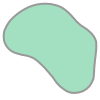

In [16]:
redbud_green = redbud.gdf[
    redbud.gdf.contains(shapely.Point(redbud_flag))
    & (redbud.gdf["course_area"] == "putting_green")
].unary_union
redbud_green_surround = redbud_green.buffer(5.0)
shapely.prepare(redbud_green_surround)
redbud_green_surround


In [17]:
surround_features = pitchmark.plotting.chart_course(redbud.gdf.clip(redbud_green_surround))

In [18]:
selected_mesh = redbud.mesh[redbud.mesh.within(redbud_green)]
grades = (alt.Chart(selected_mesh)
    .mark_geoshape(
        filled=True,
        color="lightgray",
    )
    .encode(
        color=alt.Color("slope_grade:Q", scale=alt.Scale(domain=[0, 12.0], scheme="greys"))
    )
    .project(
        type="identity",
        reflectY=True,
    )
)

In [19]:
selector = alt.selection_single(on="mouseover", nearest=True)
inclines = (
    alt.Chart(selected_mesh)
    .mark_point(
        shape="wedge",
        filled=True,
    )
    .encode(
        longitude="x",
        latitude="y",
        color=alt.condition(
            selector,
            alt.value("red"),
            alt.value("black")
        ),
        angle="slope_heading",
        size="slope_grade",
        tooltip=["z", "slope_heading", "slope_grade"],
    )
    .add_selection(selector)
    .project(
        type="identity",
        reflectY=True,
    )
    .properties(
        width=800,
        height=800,
    )
)


In [48]:
surround_features + grades + inclines

<VegaLite 4 object>

If you see this message, it means the renderer has not been properly enabled
for the frontend that you are using. For more information, see
https://altair-viz.github.io/user_guide/troubleshooting.html


In [21]:
xmin, ymin, xmax, ymax = redbud_green.bounds
xmin, ymin, xmax, ymax

(-693.6702619082821,
 -358.95588959757555,
 -655.0035154292822,
 -322.068723330571)

In [22]:
cell_size = 1.0
nx = int((xmax - xmin) / cell_size)
np.linspace(xmin, xmax, nx)

array([-693.67026191, -692.62521471, -691.5801675 , -690.5351203 ,
       -689.4900731 , -688.4450259 , -687.3999787 , -686.35493149,
       -685.30988429, -684.26483709, -683.21978989, -682.17474268,
       -681.12969548, -680.08464828, -679.03960108, -677.99455388,
       -676.94950667, -675.90445947, -674.85941227, -673.81436507,
       -672.76931787, -671.72427066, -670.67922346, -669.63417626,
       -668.58912906, -667.54408185, -666.49903465, -665.45398745,
       -664.40894025, -663.36389305, -662.31884584, -661.27379864,
       -660.22875144, -659.18370424, -658.13865704, -657.09360983,
       -656.04856263, -655.00351543])

In [23]:
xrange, xadd = divmod(xmax - xmin, cell_size)
yrange, yadd = divmod(ymax - ymin, cell_size)

In [24]:
# Square grid
# xspace = cell_size
# yspace = cell_size
# xs = np.arange(xmin + xadd/2, xmax, xspace)
# ys = np.arange(ymin + yadd/2, ymax, yspace)
# Hex grid is equal to two overlapping rectangular grids
xspace = cell_size
yspace = cell_size * np.sqrt(3)
xs1 = np.arange(xmin + xadd/2, xmax, xspace)
ys1 = np.arange(ymin + yadd/2, ymax, yspace)
grid1 = [shapely.Point(x, y) for x in xs1 for y in ys1]

In [25]:
xs2 = np.arange(xmin + xadd/2 - xspace/2, xmax, xspace)
ys2 = np.arange(ymin + yadd/2 + yspace/2, ymax, yspace)
grid2 = [shapely.Point(x, y) for x in xs2 for y in ys2]
grid_points = grid1 + grid2

In [26]:
len(grid_points)

1677

In [27]:
gdf = gpd.sjoin(
    gpd.GeoDataFrame(geometry=grid_points, crs=redbud.mesh.crs),
    redbud.mesh,
    how="left",
    predicate="within"
).clip(redbud_green)

In [28]:
len(gdf)

919

In [29]:
gdf["lat"] = gdf.geometry.x
gdf["lon"] = gdf.geometry.y
gdf

,geometry,index_right,x,y,z,normal_x,normal_y,normal_z,slope_heading,slope_grade,lat,lon
511,POINT (-670.337 -349.852),21400,-670.629205,-349.515518,70.156184,0.054354,0.021687,0.998286,68.248493,5.852041,-670.336889,-349.852052
1325,POINT (-671.837 -348.986),21181,-671.780756,-349.310223,70.185321,-0.014467,-0.005394,0.999881,249.550435,1.543975,-671.836889,-348.986027
1346,POINT (-670.837 -348.986),21179,-670.964251,-349.465774,70.170774,0.037644,0.022883,0.999029,58.705517,4.405307,-670.836889,-348.986027
468,POINT (-672.337 -348.120),21405,-672.228596,-348.310835,70.201025,0.032102,0.003988,0.999477,82.919107,3.234830,-672.336889,-348.120002
512,POINT (-670.337 -348.120),21595,-670.574010,-347.716494,70.131453,0.028550,0.005252,0.999579,79.577122,2.902900,-670.336889,-348.120002
...,...,...,...,...,...,...,...,...,...,...,...,...
504,POINT (-671.337 -323.871),19325,-671.401978,-323.507488,71.341761,-0.028635,-0.097235,0.994849,196.409392,10.136326,-671.336889,-323.871290
526,POINT (-670.337 -323.871),19794,-670.245425,-323.866956,71.338507,-0.024170,-0.071878,0.997121,198.585930,7.583299,-670.336889,-323.871290
482,POINT (-672.337 -323.871),19322,-672.559462,-323.922628,71.278957,-0.001892,-0.069644,0.997570,181.556480,6.967002,-672.336889,-323.871290
1319,POINT (-672.837 -323.005),18834,-672.436772,-322.837418,71.369071,-0.022095,-0.067215,0.997494,198.196868,7.075395,-672.836889,-323.005265


In [50]:
selector = alt.selection_single(on="mouseover", nearest=True)
inclines = (
    alt.Chart(gdf)
    .mark_point(
        shape="wedge",
        filled=True,
        color="lightgray",
    )
    .encode(
        longitude="lat",
        latitude="lon",
        color=alt.condition(
            selector,
            alt.value("red"),
            alt.Color("slope_grade:Q", scale=alt.Scale(domainMin=0.0, scheme="greys")),
        ),
        angle="slope_heading",
        size="slope_grade",
        tooltip=["x", "y", "z", "slope_heading", "slope_grade"],
    )
    .add_selection(selector)
    .project(
        type="identity",
        reflectY=True,
    )
    .properties(
        width=600,
        height=600,
    )
)


In [51]:
surround_features = pitchmark.plotting.chart_course(
    redbud.gdf.clip(redbud_green_surround)
).project(
    type="identity",
    reflectY=True,
)


In [52]:
(surround_features + inclines)

<VegaLite 4 object>

If you see this message, it means the renderer has not been properly enabled
for the frontend that you are using. For more information, see
https://altair-viz.github.io/user_guide/troubleshooting.html


In [33]:
# Need to check that Taubin smoothening does not rotate the mesh so gravity is no longer pointing down!

In [34]:
np.tan(np.deg2rad(2))

0.03492076949174773

In [35]:
redbud_green.area*9

7143.265361859608

In [36]:
triangle_mesh = pitchmark.geom.simplified_mesh(redbud.mesh.geometry)

In [37]:
np.asarray(triangle_mesh.vertices)

array([[-722.22391681, -324.2613008 ,   70.7865312 ],
       [-723.76345693, -329.83648747,   70.67842088],
       [-723.07372137, -326.63133448,   70.78920083],
       ...,
       [-596.94101047, -494.97546881,   69.30917599],
       [-596.0140074 , -497.27489922,   69.29493118],
       [-594.52874485, -498.05657249,   69.3195289 ]])

In [38]:
ground.header.parse_crs()

<Compound CRS: COMPD_CS["NAD83(2011) / Conus Albers + NAVD88 heig ...>
Name: NAD83(2011) / Conus Albers + NAVD88 height - Geoid12B (Meters)
Axis Info [cartesian|vertical]:
- [east]: X (metre)
- [north]: Y (metre)
- [up]: Gravity-related height (metre)
Area of Use:
- undefined
Datum: NAD83 (National Spatial Reference System 2011)
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich
Sub CRS:
- NAD83(2011) / Conus Albers
- NAVD88 height

In [39]:
augusta_national.gdf.crs

<Derived Projected CRS: +proj=tmerc +lon_0=-82.0198831 +lat_0=33.5023672 + ...>
Name: unknown
Axis Info [cartesian]:
- E[east]: Easting (yard)
- N[north]: Northing (yard)
- h[up]: Ellipsoidal height (yard)
Area of Use:
- undefined
Coordinate Operation:
- name: unknown
- method: Transverse Mercator
Datum: Unknown based on WGS84 ellipsoid
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [40]:
augusta_national.gdf

,name,course_area,ground_cover,geometry
168,woods,general_area,woods,"POLYGON ((-364.377 210.856, -364.295 207.363, ..."
222,rough,general_area,long_grass,"POLYGON ((-399.804 -688.022, -398.869 -692.801..."
158,woods,general_area,woods,"POLYGON ((-167.382 -395.922, -159.639 -418.350..."
138,fairway,general_area,short_grass,"POLYGON ((-106.194 -302.804, -105.249 -314.509..."
135,fairway,general_area,short_grass,"POLYGON ((-181.484 -183.993, -181.413 -186.310..."
...,...,...,...,...
112,tee,teeing_area,short_grass,"POLYGON ((-183.500 -421.879, -177.088 -422.219..."
34,bunkers,bunker,sand,"POLYGON ((-94.679 -80.650, -94.435 -81.656, -9..."
161,woods,general_area,woods,"POLYGON ((-245.263 -280.750, -230.011 -333.381..."
32,bunkers,bunker,sand,"POLYGON ((-179.462 -186.079, -179.370 -186.953..."


In [41]:
dir(gpd.io.file)

['BaseGeometry',
 'FIONA_GE_19',
 'GeoDataFrame',
 'GeoSeries',
 'Path',
 'Version',
 '_EXTENSION_TO_DRIVER',
 '_VALID_URLS',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__spec__',
 '_check_engine',
 '_check_fiona',
 '_check_pyogrio',
 '_detect_driver',
 '_expand_user',
 '_geometry_types',
 '_import_fiona',
 '_import_pyogrio',
 '_is_url',
 '_is_zip',
 '_read_file',
 '_read_file_fiona',
 '_read_file_pyogrio',
 '_to_file',
 '_to_file_fiona',
 '_to_file_pyogrio',
 '_urlopen',
 'fiona',
 'fiona_env',
 'fiona_import_error',
 'infer_schema',
 'is_integer_dtype',
 'mapping',
 'np',
 'os',
 'parse_url',
 'pd',
 'pyogrio',
 'pyogrio_import_error',
 'pyproj',
 'read_file',
 'to_file',
 'uses_netloc',
 'uses_params',
 'uses_relative',
 'warnings']

In [42]:
?gpd.io.file.to_file

Signature: gpd.io.file.to_file(*args, **kwargs)
Docstring: <no docstring>
File:      c:\users\istvan\miniconda3\envs\pitchmark_py310\lib\site-packages\geopandas\io\file.py
Type:      function

In [43]:
redbud.gdf.to_csv(folder / "redbud_gdf.csv")

In [44]:
pd.from_csv(folder / "redbud_gdf.csv")

NameError: name 'pd' is not defined

In [ ]:
redbud_df_from_csv = pd.read_csv(folder / "redbud_gdf.csv", index_col=0)
geometry = gpd.GeoSeries.from_wkt(redbud_df_from_csv["geometry"])
gdf = gpd.GeoDataFrame(data=redbud_df_from_csv, geometry=geometry)

In [ ]:
redbud.mesh.to_csv(folder / "redbud_mesh.csv")

,name,course_area,ground_cover,geometry
197,woods,general_area,woods,"POLYGON ((-591.987 -508.373, -589.120 -506.813..."
100,tee,teeing_area,short_grass,"POLYGON ((-612.319 -460.423, -592.200 -499.142..."
217,rough,general_area,long_grass,"POLYGON ((-591.987 -508.373, -595.769 -509.971..."
4,water_hazard,penalty_area,water,"POLYGON ((-695.338 -347.746, -694.647 -347.528..."
145,fairway,general_area,short_grass,"POLYGON ((-697.073 -311.733, -692.917 -315.942..."
172,woods,general_area,woods,"POLYGON ((-596.440 -362.890, -600.160 -365.364..."
28,bunkers,bunker,sand,"POLYGON ((-654.425 -351.048, -654.059 -350.162..."
29,bunkers,bunker,sand,"POLYGON ((-694.596 -342.749, -694.372 -342.021..."
70,green,putting_green,green,"POLYGON ((-693.538 -332.827, -693.203 -332.135..."
164,woods,general_area,woods,"POLYGON ((-655.582 -319.462, -653.935 -319.110..."
